# OWT-based blending of chlorophyll-a algorithms

No single chlorophyll-a (Chl-a) algorithm works in all waters: blue-green band ratios
are suited to clear waters, red-edge algorithms to turbid and eutrophic waters. This
tutorial shows how GRSl2bgen uses the Optical Water Types (OWT) to **select and blend**
the most suitable algorithms pixel by pixel, following the recipe of
Tavares et al. (2025).

For each pixel, the $K$ best-matching OWT classes $c_1, \dots, c_K$ (from the
Spyrakos et al. 2018 database) are kept with their spectral angles
$\theta_1 \le \dots \le \theta_K$. Each class is assigned an algorithm
$\mathcal{A}(c)$, and the estimates are averaged with weights inversely proportional
to the spectral angle:

$$
\mathrm{Chl}_{\mathrm{blend}} = \frac{\sum_{k=1}^{K} w_k\, \mathrm{Chl}_{\mathcal{A}(c_k)}}{\sum_{k=1}^{K} w_k},
\qquad w_k = \frac{1}{\theta_k + \varepsilon}
$$

| Spyrakos OWT | Algorithm |
|---|---|
| 1, 6, 10 | Gons et al. (2005) |
| 2, 4, 5, 11, 12 | NDCI (Mishra & Mishra, 2012) |
| 7, 8 | Gilerson et al. (2010), two-band |
| 3, 9, 13 | NASA OC2 |

The equations of each algorithm are given in {doc}`../algorithms`. Start with the
{doc}`grsl2bgen_owt_minimal` tutorial if you are new to the OWT classification.

In [1]:


import os
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import xarray as xr
import rioxarray as rio
import pandas as pd
import datetime as dt
import cartopy.crs as ccrs

import GRSl2bgen

opj = os.path.join

print(f'-GRSl2bgen: {GRSl2bgen.__version__}')

-GRSl2bgen: 1.0.0


## Set the input path

`l2a_path` points to a GRS L2A product (`.nc` file, `.zarr` store, or directory with
the `_anc.nc` ancillary file). Replace it with the path of your own image.

In [2]:

l2a_path ='/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'


## Open and check the input L2A image

{py:class}`GRSl2bgen.product.Product` loads the product lazily as an `xarray.Dataset`
containing `Rrs` (sr$^{-1}$), the sunglint reflectance `BRDFg`, and the `mask`/`flags`
variables.

In [3]:
prod = GRSl2bgen.Product(l2a_path)
prod.raster

INFO:root:Load L2A from files
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/GRSl2bgen/GRSl2bgen/product.py:106: UserWarning: The specified chunks separate the stored chunks along dimension "y" starting at index 1024. This could degrade performance. Instead, consider rechunking after loading.
  self.raster = xr.open_dataset(main_file, decode_coords='all', chunks=chunks)
/home/harmel/Dropbox/Dropbox/work/git/satellite_app/GRSl2bgen/GRSl2bgen/product.py:106: UserWarning: The specified chunks separate the stored chunks along dimension "x" starting at index 1024. This could degrade performance. Instead, consider rechunking after loading.
  self.raster = xr.open_dataset(main_file, decode_coords='all', chunks=chunks)


<xarray.Dataset> Size: 2GB
Dimensions:             (wl: 11, y: 3206, x: 4400)
Coordinates:
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    time                datetime64[ns] 8B ...
  * x                   (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05
  * y                   (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (wl, y, x) float64 1GB dask.array<chunksize=(11, 1024, 1024), meta=np.ndarray>
    BRDFg               (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    aot550              (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    wind                (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                (y, x) uint8 14MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    vza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    sza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    raa                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    flags               (y, x) int64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dem                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

Get the map projection, pixel size and acquisition date for the figures.

In [4]:
raster = prod.raster
crs = raster.rio.crs
str_epsg = str(crs)
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)
x_res, y_res = raster.rio.resolution()
pixel_area = np.abs(x_res*y_res)
date = str(raster.time.dt.strftime('%Y/%m/%d').values)

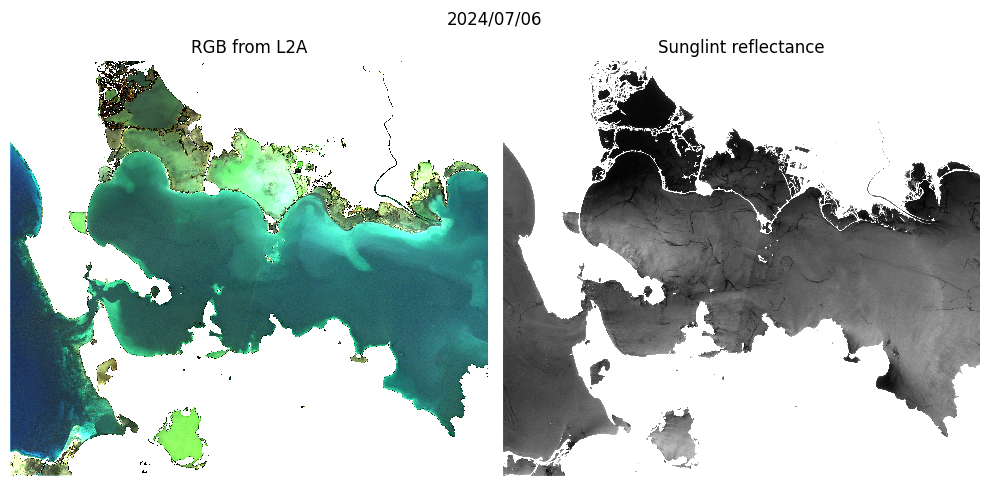

In [5]:


nrows=1
ncols=2
alpha=0.3
l2a_rgb = raster.Rrs.sel(wl= [670,565,490],method='nearest' )
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.,5*nrows),subplot_kw={'projection': proj}) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.07,)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]   

ax=axs[0]


bcmap = mpl.colors.ListedColormap([(0,0,0,0),'green','blue'])
# omni_mask.plot.imshow(cmap=bcmap,alpha=alpha,add_colorbar=False,ax=ax)
l2a_rgb.plot.imshow(rgb='wl', robust=True,ax=ax)
raster['BRDFg'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,vmax=0.04,ax=axs[1],add_colorbar=False)
 

ax.set_title("RGB from L2A")
axs[1].set_title("Sunglint reflectance")

#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])  # Left, bottom, width, height.
#cbar = fig.colorbar(im, cax=cbar_ax, extend='both', orientation='horizontal')
#cbar.set_label('$SPM\ (mg\cdot L^{-1})$')
plt.suptitle(date)
plt.tight_layout()


## OWT classification with Spyrakos et al. (2018)

The image is classified with the Spectral Angle Mapper against the 13 OWT of
[Spyrakos et al. (2018)](https://aslopubs.onlinelibrary.wiley.com/doi/10.1002/lno.10674).
This time the **three** best classes are kept (`Nclasses_to_be_saved=3`), so that
they can be blended.

In [6]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018',Nclasses_to_be_saved=3)


Mean spectra of the 13 OWT:

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='$Wavelength\\ (nm)$', ylabel='$Standardized\\ R_{rs}\\ (nm^{-1})$'>)

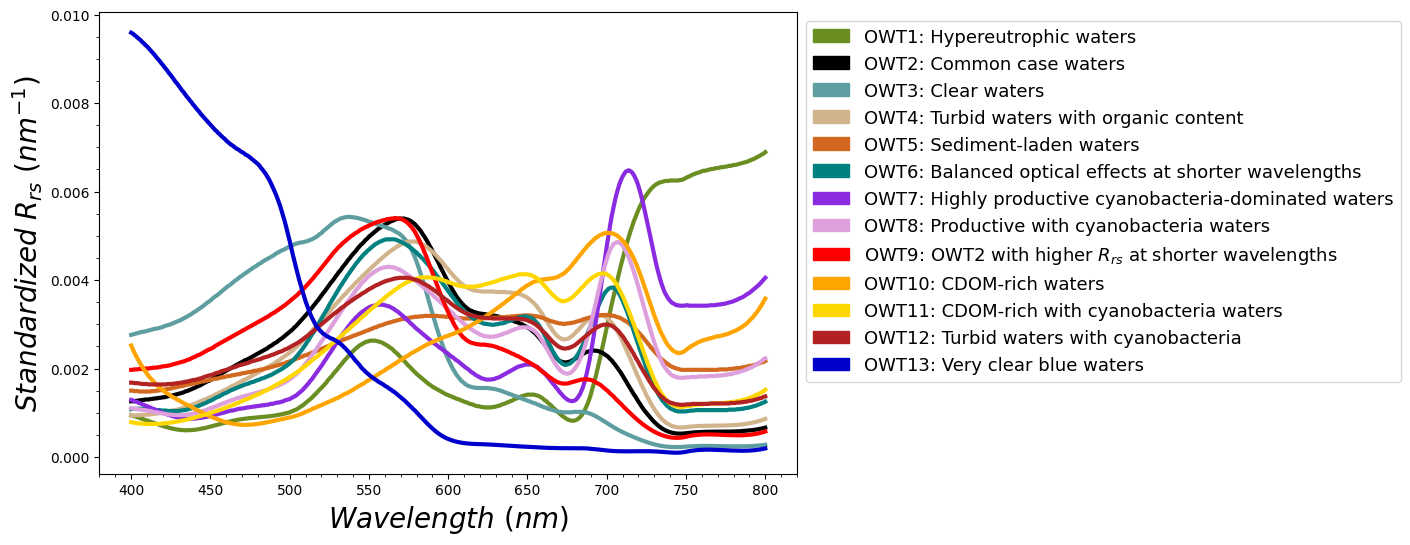

In [7]:
OWT.plot()

Run the classification (lazy with dask). The variables `owt_index` and `owt_dist`
now have an extra `Nclasses` dimension of size 3, ordered from the best to the
third-best class.

In [8]:
xowt_prod = OWT.multi_process()

INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product


In [9]:
xowt_prod

<xarray.Dataset> Size: 339MB
Dimensions:      (Nclasses: 3, y: 3206, x: 4400)
Coordinates:
    time         datetime64[ns] 8B 2024-07-06T09:15:59
  * x            (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05 5.097e+05
    spatial_ref  int64 8B 0
  * y            (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06 4.299e+06
  * Nclasses     (Nclasses) int64 24B 0 1 2
Data variables:
    owt_dist     (Nclasses, y, x) float32 169MB nan nan nan nan ... nan nan nan
    owt_index    (Nclasses, y, x) float32 169MB nan nan nan nan ... nan nan nan

For each rank (best, second, third class), map the OWT (left) and the spectral angle
(right). The angle increases with the rank.

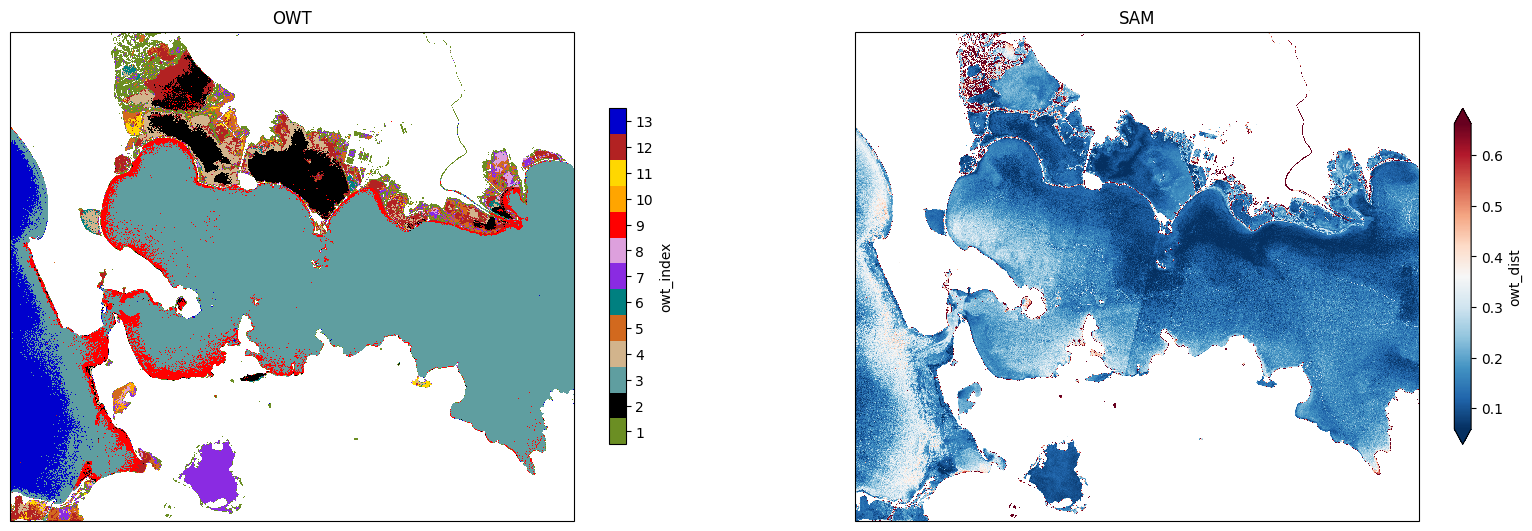

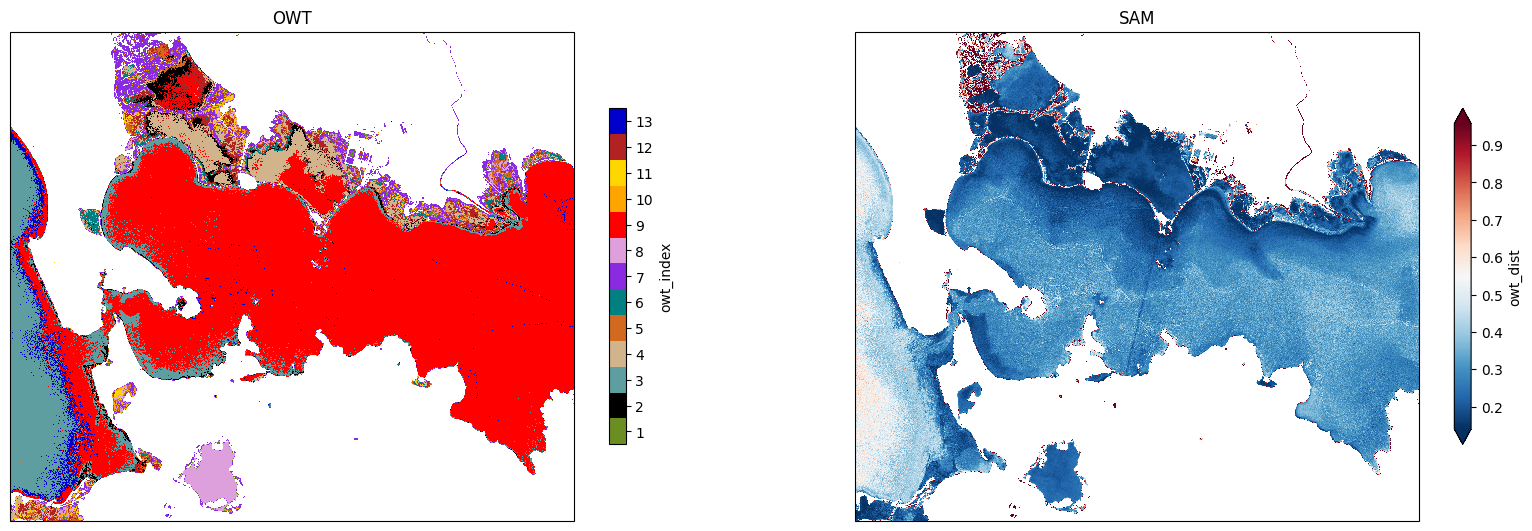

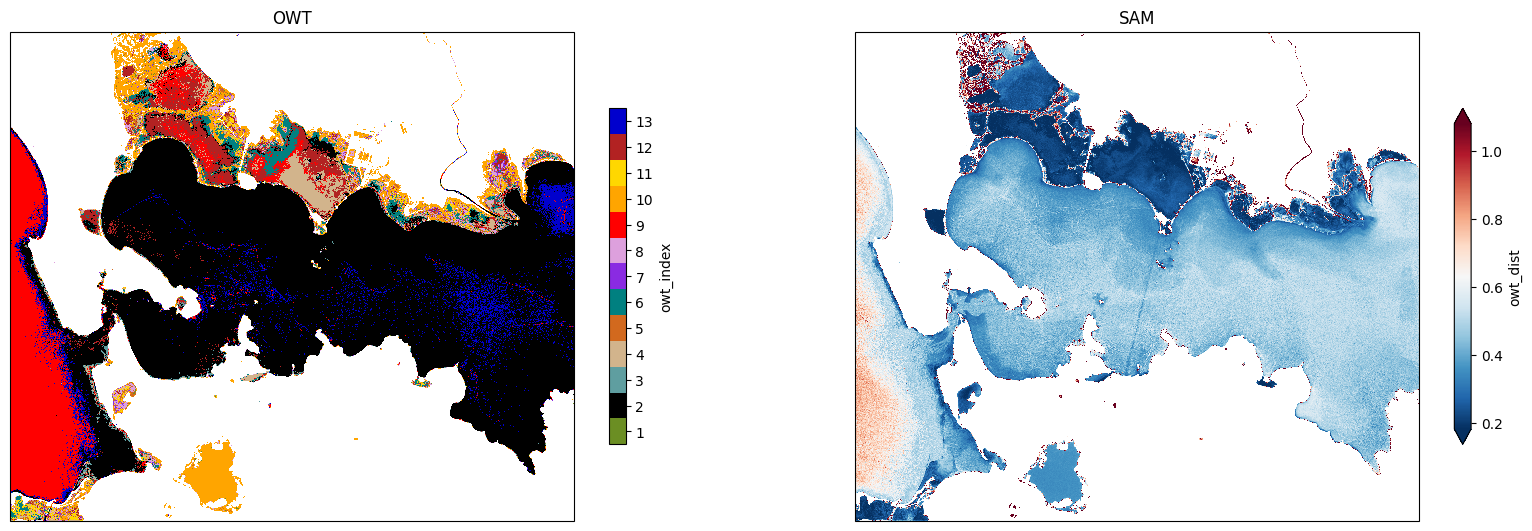

In [10]:
for iclass in range(3):
    fig = plt.figure(figsize=(20, 15))
    
    ax = plt.subplot(2, 2, 1, projection=proj)
    xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
    ax.set_title('OWT')
    cmap = plt.get_cmap('RdBu_r')#,13)
    ax = plt.subplot(2, 2, 2, projection=proj)
    xowt_prod.owt_dist.isel(Nclasses=iclass).plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})
    ax.set_title('SAM')


## Blending with the best class only ($K = 1$)

With $K = 1$ the blending reduces to a hard switch: every pixel gets the algorithm of
its best class. Algorithm changes produce visible discontinuities at OWT boundaries.

{py:class}`GRSl2bgen.chlorophyll_a.Chl` holds the Chl-a algorithms;
{py:meth}`~GRSl2bgen.chlorophyll_a.Chl.owt_blending` applies the recipe to the OWT product:

In [11]:

chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=1)

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)


Text(0.5, 1.0, 'Chlorophyll-a')

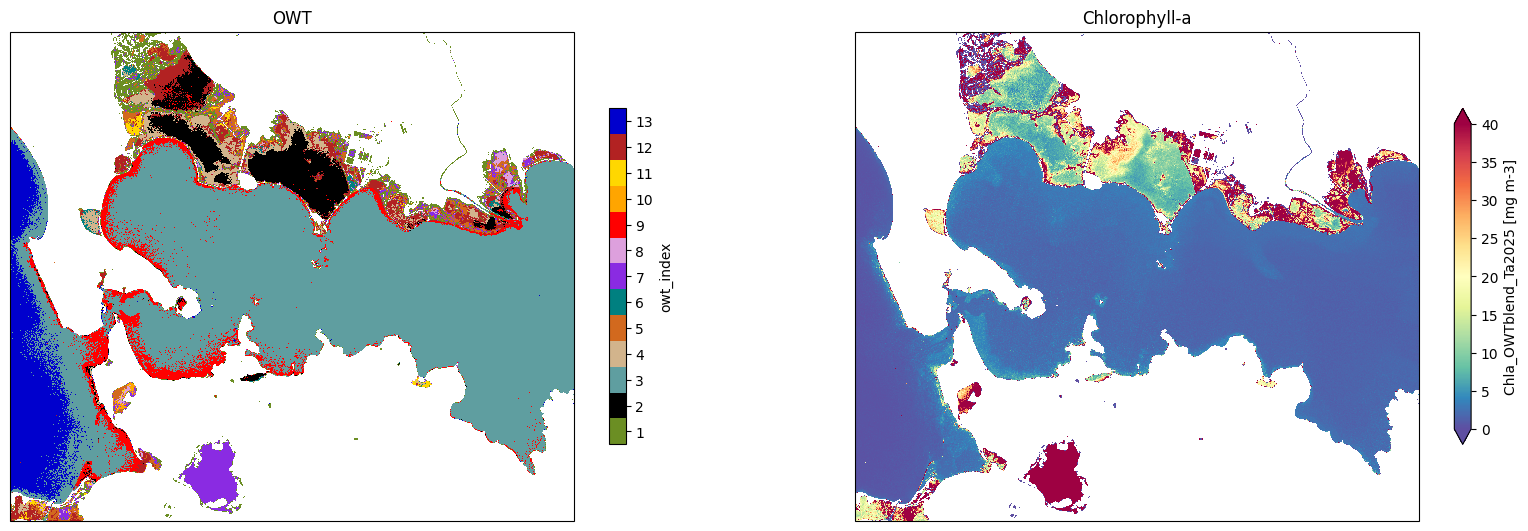

In [12]:
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a')


## Blending the two best classes ($K = 2$)

The two best classes contribute, weighted by $1/\theta_k$. Near OWT boundaries, where
the two angles are close, the result is a smooth transition between the two
algorithms. $K = 2$ is the default of the processing chain.

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)


Text(0.5, 1.0, 'Chlorophyll-a')

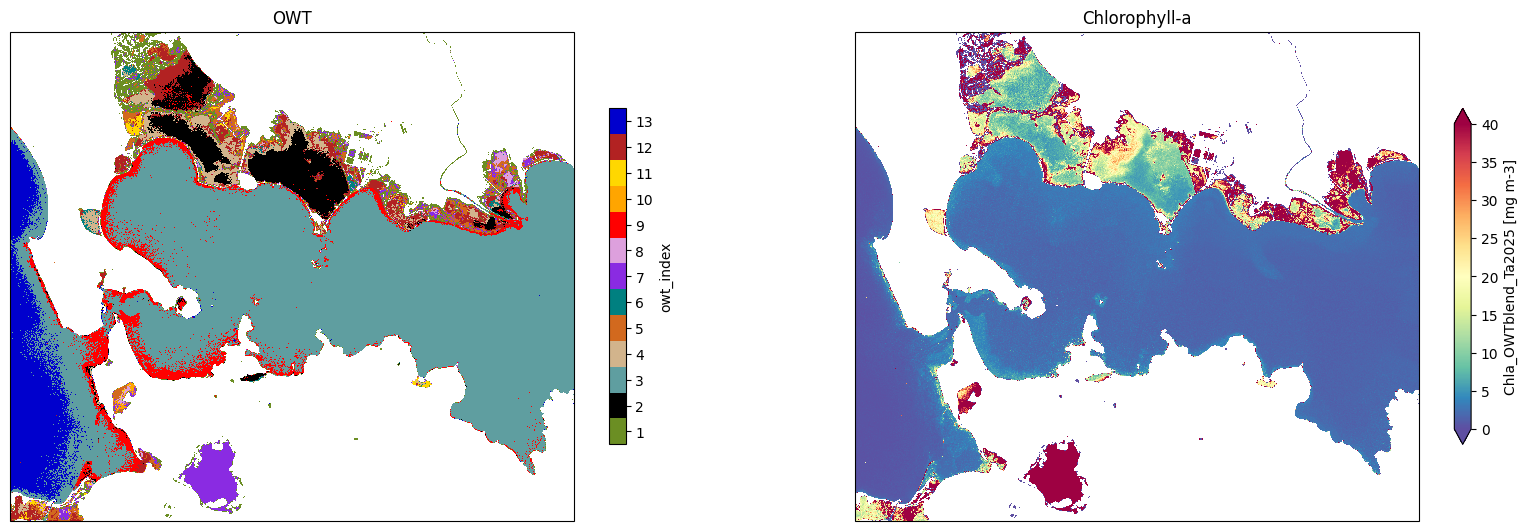

In [13]:
chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=2)
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a')


## Blending the three best classes ($K = 3$)

Adding a third class further smooths the field, at the cost of including algorithms
from less representative classes.

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)


Text(0.5, 1.0, 'Chlorophyll-a')

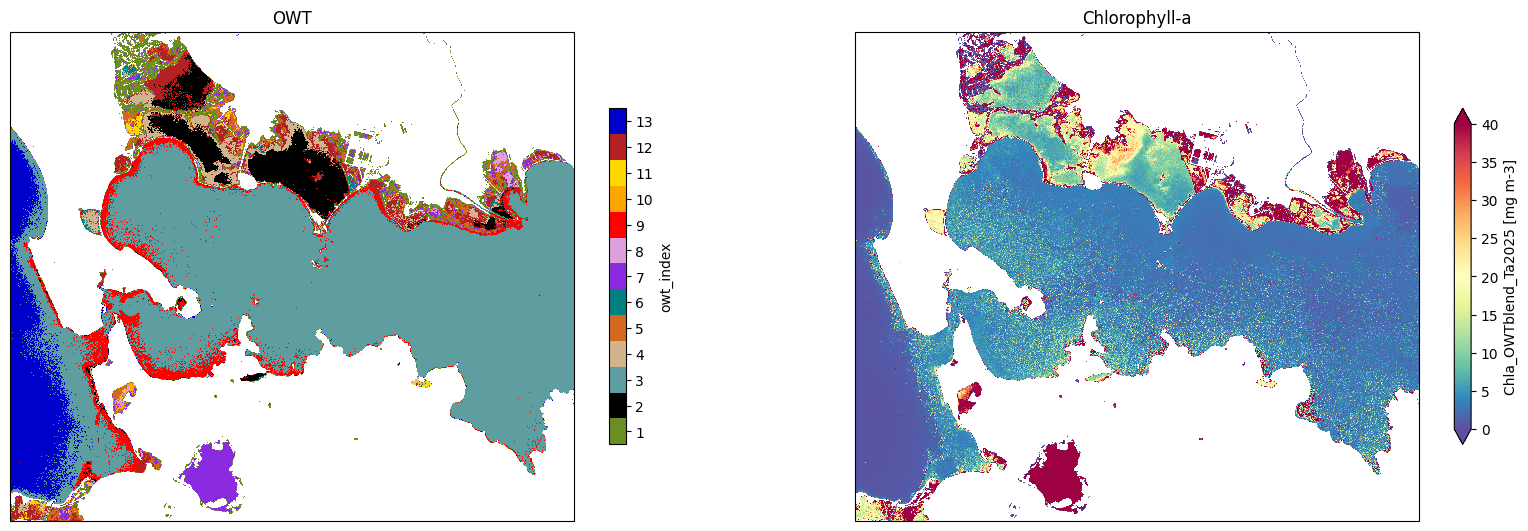

In [14]:
chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=3)
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a')

## Advanced: write your own blending

The cells below reproduce {py:meth}`GRSl2bgen.chlorophyll_a.Chl.owt_blending` step by step. Modify
the recipe (class-to-algorithm assignment, coefficients, number of classes) to build
your own blended product.

First, get the reflectance image:

In [15]:
# ---------------------------------------------------
# get your Rrs image
# ---------------------------------------------------
Rrs_img = prod.raster.Rrs

Set the number of top OWT classes $K$ to blend:

In [16]:
# ---------------------------------------------------
# set number of top OWT classes to be used
# ---------------------------------------------------
Nclasses=2

Classify the image, keeping the $K$ best classes:

In [17]:
# ---------------------------------------------------
# get your OWT classification product
# ---------------------------------------------------
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018',Nclasses_to_be_saved=Nclasses)
xowt_prod = OWT.multi_process()

INFO:root:OWT classification
INFO:root:success
INFO:root:construct xarray owt product


Create the Chl-a object that provides the individual algorithms (`chl_gons`,
`chl_ndci`, `chl_gilerson2`, `OC2`, ...):

In [18]:
# ---------------------------------------------------
# get GRSl2bgen object for Chl-a computation
# ---------------------------------------------------
chl_process = GRSl2bgen.Chl(prod.raster)

Keep only the first $K$ classes (in case more were saved):

In [19]:
# ---------------------------------------------------
# set number of top OWT classes to be used for algorithm weighting
# ---------------------------------------------------
Nclasses = np.min([len(xowt_prod.Nclasses), Nclasses])
xowt_prod = xowt_prod.isel(Nclasses=range(Nclasses))

Compute the normalisation term $\sum_k w_k = \sum_k 1/(\theta_k + \varepsilon)$ for
each pixel:

In [21]:
# ---------------------------------------------------
# reshape for Nclasses 
# ---------------------------------------------------
Nclasses = np.min([len(xowt_prod.Nclasses), Nclasses])
xowt_prod = xowt_prod.isel(Nclasses=range(Nclasses))
eps=1e-6

# ---------------------------------------------------
# Compute norm from owt SAM distance for each pixel
# ---------------------------------------------------
norm = 1 / (xowt_prod.owt_dist + eps)
# the summation assumes nan identical to 0
norm = norm.sum('Nclasses')
# replace empty value from 0 to nan
norm = norm.where(norm > 0)

Apply the recipe: for each group of classes, mask the pixels/ranks belonging to the
group, compute the corresponding algorithm, and accumulate
$w_k\,\mathrm{Chl}_{\mathcal{A}(c_k)}$. The sum over the ranks divided by the
normalisation term gives the blended Chl-a:

In [23]:
# ---------------------------------------------------
# Recipe and algorithm application
# ---------------------------------------------------
# OWT 1, 6, 10: Gons
owt_index_to_keep = [1, 6, 10]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla = (chl_process.chl_gons(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 2, 4, 5, 11, 12 : NDCI
owt_index_to_keep = [2, 4, 5, 11, 12]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla += (chl_process.chl_ndci(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 7, 8 : Gilerson2
owt_index_to_keep = [7, 8]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla += (chl_process.chl_gilerson2(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 3, 9 ,13: OC2 for clear waters
owt_index_to_keep = [3, 9, 13]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
acoef = [0.2236, -1.8296, 1.9094, -2.9481, -0.1718]
chla += (chl_process.OC2(Rrs_img.where(mask), acoef) * weights).fillna(0)

# get final product after normalization
chla = chla.sum('Nclasses') / norm



Map of the resulting blended Chl-a (mg m$^{-3}$):

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log10
  return self.func(*new_argspec)
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)


Text(0.5, 1.0, 'Chlorophyll-a')

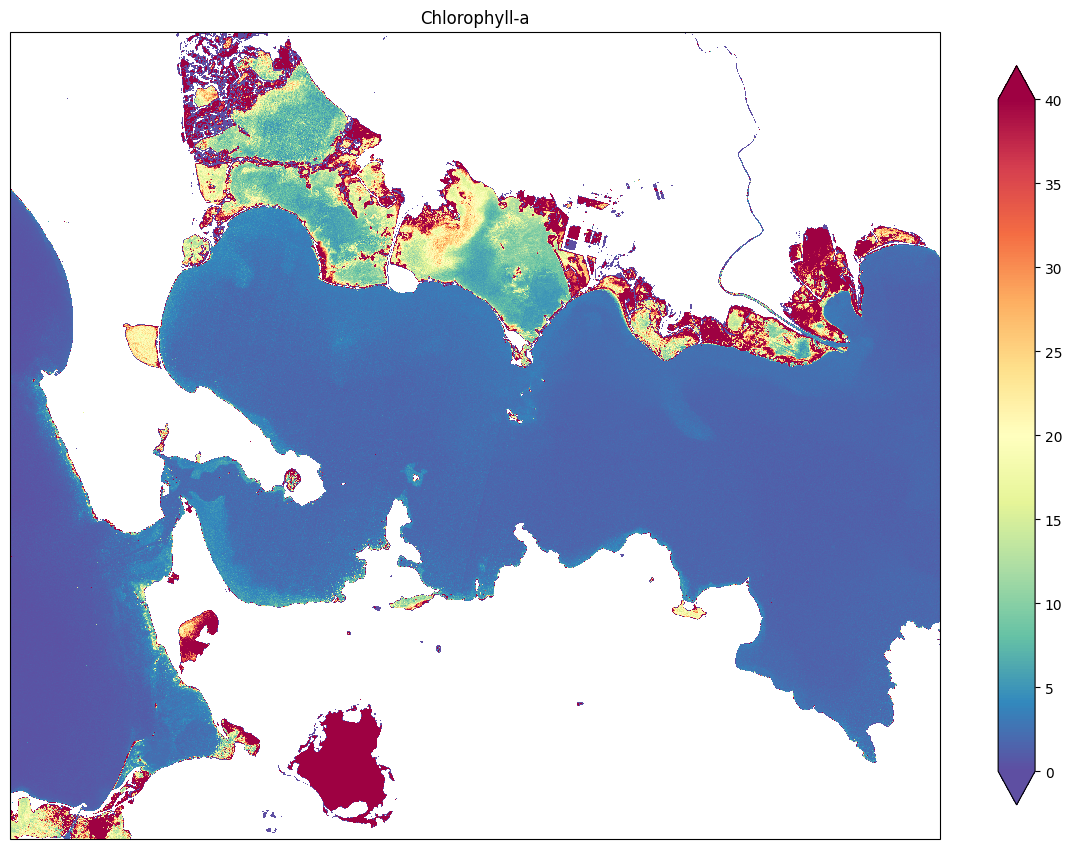

In [24]:
fig = plt.figure(figsize=(15, 15))

ax = plt.subplot( projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a')

## References

- Spyrakos, E., et al. (2018). Optical types of inland and coastal waters.
  *Limnology and Oceanography*, 63, 846--870.
- Tavares, M. H., et al. (2025). A framework to retrieve water quality parameters in
  small, optically diverse freshwater ecosystems using Sentinel-2 MSI imagery.
  *Remote Sensing*, 17, 2729.